In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

In [3]:
df = pd.read_csv('h:W.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [4]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [5]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


Text(0, 0.5, 'Height')

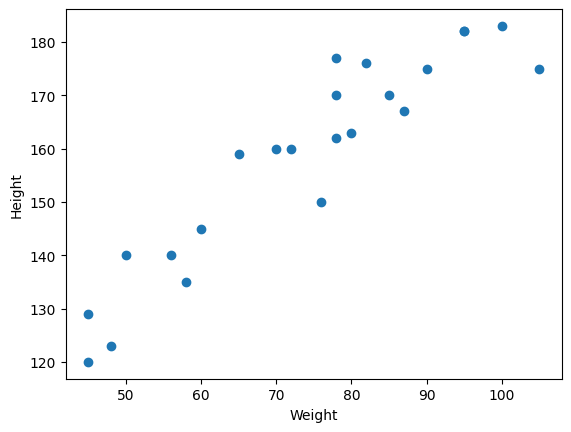

In [7]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [8]:
## Divide data into dependent and independent features. 
X = df[['Weight']]
y = df['Height']

In [8]:
X

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [9]:
# Now train the data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)
## 0.20 mean that for testing only 20% data will use from the above data and remaining for training.

In [10]:
X_train.shape,X_test.shape,y_test.shape,y_train.shape

((18, 1), (5, 1), (5,), (18,))

In [11]:
## Standardize the dataset train inpedenedent data. 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# using scikit-learn's StandardScaler, the mean and standard deviation are calculated from the 
# training data using fit_transform and then used to scale the test data via the transform method [1]. 
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

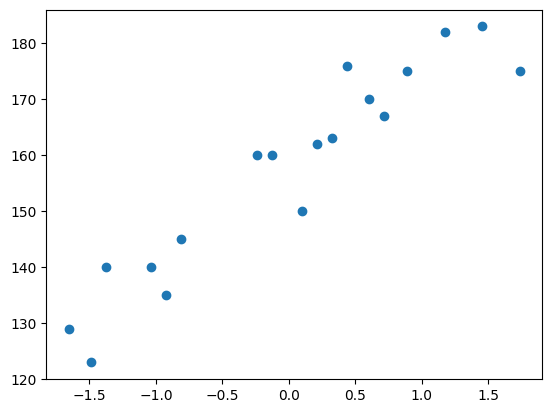

In [12]:
plt.scatter(X_train,y_train)

In [13]:
## Now apply Linear Regression
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [14]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
print("The Slope or Coefficient is ",regression.coef_)
print("The Intercept is ",regression.intercept_)

The Slope or Coefficient is  [17.03440872]
The Intercept is  157.5


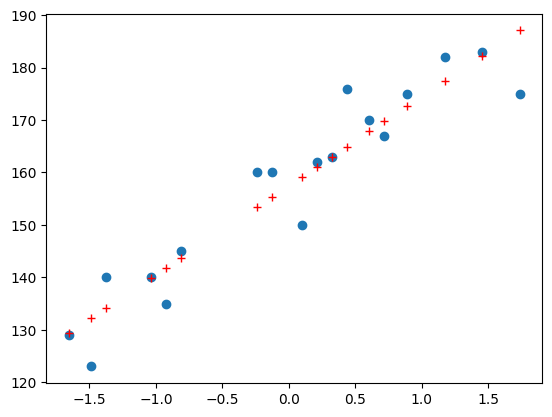

In [16]:
# Now Draww the best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),'r+') ## prediction for X_train data

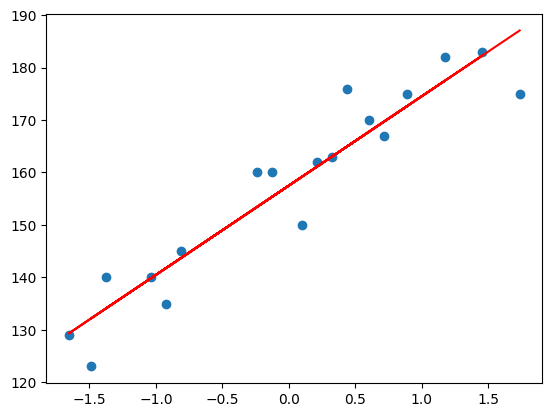

In [17]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),'r') ## prediction for X_train data

In [18]:
y_pred_train = regression.predict(X_train)

In [19]:
y_pred_train,X_train

(array([187.0869102 , 141.82375282, 182.27168069, 161.08467086,
        132.19329381, 177.45645118, 129.3041561 , 143.74984463,
        153.38030364, 159.15857905, 134.11938561, 139.89766102,
        155.30639545, 172.64122168, 164.93685446, 167.82599217,
        169.75208397, 163.01076266]),
 array([[ 1.73689094],
        [-0.92026952],
        [ 1.4542143 ],
        [ 0.21043706],
        [-1.48562281],
        [ 1.17153765],
        [-1.6552288 ],
        [-0.80719886],
        [-0.24184557],
        [ 0.0973664 ],
        [-1.37255215],
        [-1.03334018],
        [-0.12877492],
        [ 0.88886101],
        [ 0.43657837],
        [ 0.60618436],
        [ 0.71925502],
        [ 0.32350772]]))

## Prediction of Train Data
1. predicted Height output = intercept + coefficient(Weight) [Weight mean (train_weight)]
2. y_pred_train = 157.5 + 17.03(X_train)

## Prediction of Test Data
1. predicted Height output = intercept + coefficient(Weight) [Weight mean (test_weight)]
2. y_pred_test = 157.5 + 17.03(X_test)


In [20]:
y_pred_test = regression.predict(X_test)

In [21]:
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

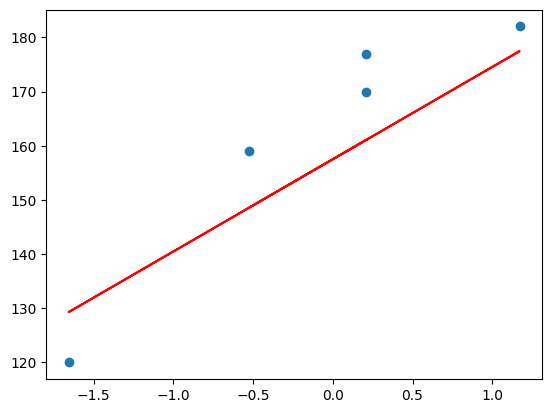

In [22]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regression.predict(X_test),'r')

In [23]:
## To check the performance 
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [24]:
mse = mean_squared_error(y_test,y_pred_test) # y_test actuall data, y_pred_test predicted data.
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
print(mse,"\n",mae,"\n",rmse)

109.77592599051664 
 9.822657814519232 
 10.477400726827081


In [25]:
# Now to check the accuracy of my own model
# so import r2_score
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred_test)
print(score)
# It mean that my model have 77.6% accouracy. 

0.776986986042344


In [26]:
## Do Some assumption
scaled_weight = scaler.transform([[80]])
scaled_weight

/Users/interlink/Desktop/ML_PYTHON_01/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [27]:
scaled_weight[0]

array([0.32350772])

In [28]:
print("The height prediction for weight 80kg = ",regression.predict([scaled_weight[0]]))
# if a person weight is 80kg, his/her height will be 163cm according to this model. 

The height prediction for weight 80kg =  [163.01076266]


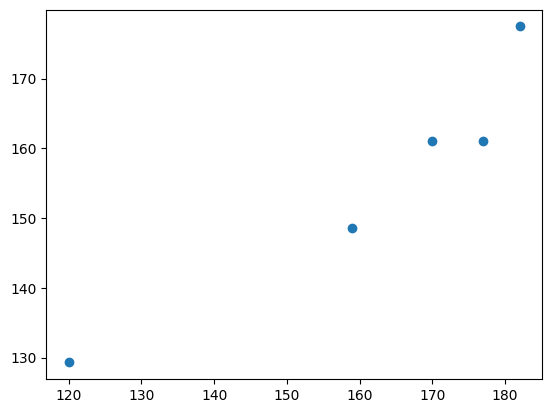

In [29]:
# Now do some important assumptions
plt.scatter(y_test,y_pred_test)
# if you get a linear model so its a good model.

In [30]:
## Second Assumption is residuals
residuals = y_test - y_pred_test
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

/var/folders/d0/c7x05x6n72sb_gqml775ghc00000gn/T/ipykernel_1248/655059355.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

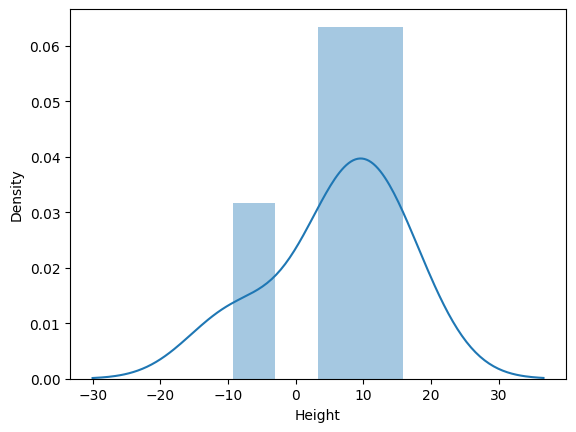

In [31]:
# now plot is 
import seaborn as sns
sns.distplot(residuals,kde=True)

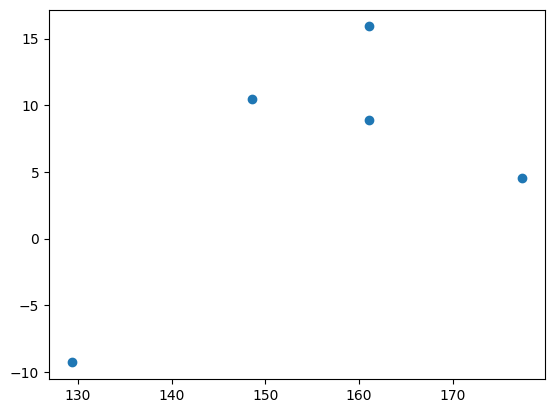

In [32]:
plt.scatter(y_pred_test,residuals)
# uniform distrbution 

In [33]:
weight = int(input("Enter Your Weight"))
sclWeight = scaler.transform([[weight]])
predictedHeight = regression.predict(sclWeight)
print(predictedHeight)

[163.01076266]


/Users/interlink/Desktop/ML_PYTHON_01/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
